# Races table audit (raw data, before cleaning)

This section explores `races.csv` **without changing it**. Every check reads the raw table directly. Anything that looks like a transformation (boolean masks, parsed dates) is built on a temporary copy, so the raw table stays untouched for the later before/after comparison.

**Why start with races?** Every other table (results, qualifying, standings, pit stops, sprint results) links to a race through `raceId`. If the races table is unreliable, every join built on it is too.

**Note on missing values:** this dataset stores missing values as the literal text `\N`, which pandas does **not** recognise as missing. We count it explicitly using the `SENTINEL` constant defined in the setup.

## 0. Setup
Imports, the data path, and loading every CSV into `raw_before` exactly as stored on disk (no `na_values` argument, so `\N` stays visible as text).

In [133]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'

# list the files in the dataset
for f in sorted(os.listdir(DATA_DIR)):
    print(f)

circuits.csv
constructor_results.csv
constructor_standings.csv
constructors.csv
driver_standings.csv
drivers.csv
lap_times.csv
pit_stops.csv
qualifying.csv
races.csv
results.csv
seasons.csv
sprint_results.csv
status.csv


In [134]:
# load every table exactly as stored on disk
raw_before = {f[:-4]: pd.read_csv(os.path.join(DATA_DIR, f))
              for f in sorted(os.listdir(DATA_DIR)) if f.endswith('.csv')}

races = raw_before['races']
SENTINEL = '\\N'   # the dataset's placeholder for a missing value

## 1. Dataset overview
**Question:** what tables do we have, and how big is each one?

Table sizes show which tables dominate the dataset and give an early hint of coverage differences between tables (for example, how many qualifying rows exist compared with result rows).

In [135]:
pd.DataFrame({name: df.shape for name, df in raw_before.items()},
             index=['rows', 'columns']).T

,rows,columns
circuits,77,9
constructor_results,12625,5
constructor_standings,13391,7
constructors,212,5
driver_standings,34863,7
drivers,861,9
lap_times,589081,6
pit_stops,11371,7
qualifying,10494,9
races,1125,18


**Findings**
- The dataset has the 14 tables listed in the brief.
- `results` has 26,759 rows but `qualifying` only 10,494 (about 39%). Qualifying data therefore exists for well under half of all driver-race entries. This is the first evidence of the **qualifying-coverage drift** that the brief lists as a known limitation; Section 3 measures it per season.
- `lap_times` is by far the largest table (589,081 rows), but it is post-race information and can never be a feature.
- `sprint_results` has 360 rows, which equals 18 sprint weekends × 20 drivers (confirmed in 2.8).

## 2. The races table
### 2.1 Structure
**Question:** what columns does the races table have, and how did pandas read them?

We expect text columns to load as `object`. A column that should be numeric or a date will also load as `object` if it contains `\N`, so the dtypes already hint at where placeholders are hiding.

In [136]:
races.head(25)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
5,6,2009,6,6,Monaco Grand Prix,2009-05-24,12:00:00,http://en.wikipedia.org/wiki/2009_Monaco_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
6,7,2009,7,5,Turkish Grand Prix,2009-06-07,12:00:00,http://en.wikipedia.org/wiki/2009_Turkish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
7,8,2009,8,9,British Grand Prix,2009-06-21,12:00:00,http://en.wikipedia.org/wiki/2009_British_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
8,9,2009,9,20,German Grand Prix,2009-07-12,12:00:00,http://en.wikipedia.org/wiki/2009_German_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
9,10,2009,10,11,Hungarian Grand Prix,2009-07-26,12:00:00,http://en.wikipedia.org/wiki/2009_Hungarian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [137]:
# column names and the data type pandas assigned to each
races.dtypes

raceId          int64
year            int64
round           int64
circuitId       int64
name           object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object

`info()` reports non-null counts. Because `\N` is stored as text, pandas counts it as a real value, so these counts **cannot** be used to judge missingness. The point of this cell is to demonstrate that.

In [138]:
races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB


**Findings**
- Only 4 columns are integers (`raceId`, `year`, `round`, `circuitId`); the other 14 are `object`.
- `info()` reports 1,125 non-null values in **every** column, although several columns are more than 90% `\N` (see 2.5). This proves pandas cannot detect the sentinel, so missingness must be counted explicitly and `\N` converted to a real missing value during cleaning.
- `date` is stored as text and must be converted to a datetime during cleaning (semantic typing).
- `raceId` and `circuitId` are identifiers, not quantities, so they are excluded from numeric summaries and correlations.
- `head()` shows that **`raceId` is not in time order**: `raceId` 1 is the 2009 Australian GP and `raceId` 18 is the 2008 Australian GP. Races must never be ordered by `raceId`; we use `date` or `(year, round)` instead. This matters for every "past races only" feature.

### 2.2 Keys
**Question:** is `raceId` a valid primary key (unique and never empty)? Is the pair `(year, round)` also unique, so it can serve as an alternative identifier for a race?

The milestone brief requires primary keys to be unique and non-null before any joins are built on them.

In [139]:
print('rows:', len(races))
print('raceId unique:', races.raceId.is_unique)
print('raceId nulls :', races.raceId.isna().sum())
print('(year, round) unique:', not races.duplicated(['year', 'round']).any())

rows: 1125
raceId unique: True
raceId nulls : 0
(year, round) unique: True


**Findings**
- `raceId` is unique and never empty, so it is a valid primary key.
- `(year, round)` is also unique, so it can identify a race and put races in order.

### 2.3 Season structure
**Question:** how many races does each season have, and are rounds numbered 1, 2, 3, ... with no gaps or repeats?

Season length matters because it changes what "typical" looks like across eras (for example, how many chances a driver has to score a podium in a season), and because later features that count "past races in this season" rely on a clean round sequence.

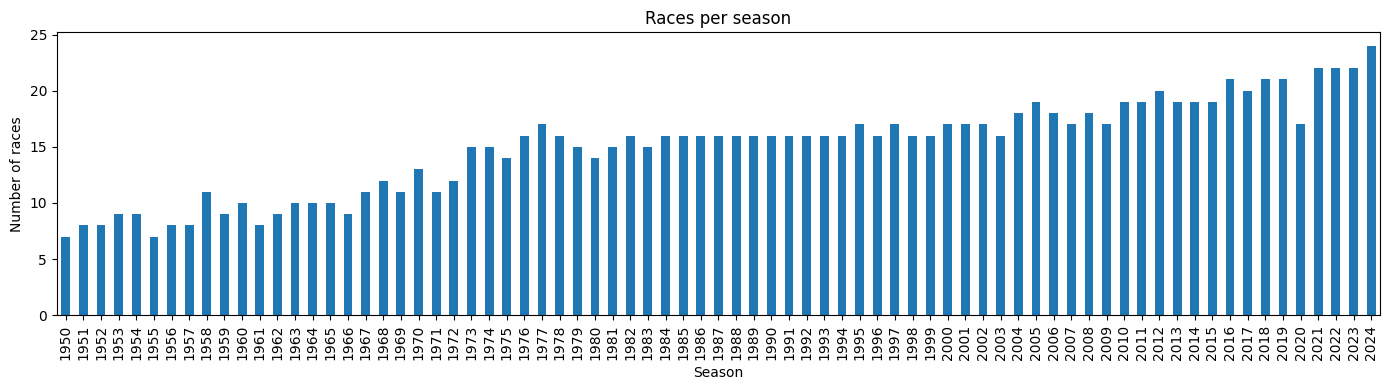

In [140]:
ax = races.year.value_counts().sort_index().plot(kind='bar', figsize=(14, 4))
ax.set_title('Races per season')
ax.set_xlabel('Season')
ax.set_ylabel('Number of races')
plt.tight_layout()
plt.show()

The cell below lists any season whose rounds do not run 1..n without gaps or repeats. **An empty table means no problems were found.**

In [141]:
s = races.groupby('year')['round'].agg(['count', 'min', 'max', 'nunique'])
s[(s['min'] != 1) | (s['max'] != s['count']) | (s['nunique'] != s['count'])]

,count,min,max,nunique
year,,,,


**Findings**
- Season length grows from 7 races in 1950 to 24 in 2024, with a dip to 17 in 2020 (COVID).
- In every one of the 75 seasons, rounds run 1..n with no gaps or repeats.

**Implications**
- A count such as "podiums this season" means something different in an 8-race season than in a 24-race season, so form features should be **rates** (for example, podiums per race entered) rather than raw counts.
- The clean round numbering makes features such as "races so far this season" safe to build.

### 2.4 Dates
**Question:** does each race's `date` fall in the season given by `year`, can every date be read, and does round order match calendar order within each season?

If round order matches calendar order, `(year, round)` can be used to put races in time order. That ordering is needed later for leakage-safe features that may only use races **before** the one being predicted. Dates are parsed on a temporary copy (`tmp`), so `races` is not modified.

In [142]:
# the year inside the date string matches the year column
print('date/year mismatches:', (races['date'].str[:4] != races['year'].astype(str)).sum())

# every date can be parsed, and dates never go backwards as round increases
tmp = races.assign(d=pd.to_datetime(races['date'], errors='coerce'))
print('unparseable dates:', tmp.d.isna().sum())
print(tmp.sort_values(['year', 'round']).groupby('year')['d']
         .apply(lambda x: x.is_monotonic_increasing).value_counts())

date/year mismatches: 0
unparseable dates: 0
d
True    75
Name: count, dtype: int64


**Findings**
- No race date falls outside its season, every date can be parsed, and in all 75 seasons dates never go backwards as `round` increases.

**Implications**
- `(year, round)` and `date` give the same order, so either can be used to decide which races came **before** the one being predicted. This is the basis for the leakage-safe form and standings features.
- Season boundaries are clean, so a split by year puts every race in exactly one of the training, validation and test sets.
- `is_monotonic_increasing` allows ties. If races are ever ordered by `date` alone, check that no two races in a season share a date.

### 2.5 Missingness
**Question:** which columns contain `\N`, how much of each column is affected, and from which season does each column start being recorded?

The heatmap shows the share of `\N` per column for every season (one row per season). The table underneath gives the exact numbers, including the first season in which each column has a value and the last season in which it is still missing. If a column's last missing season comes right before its first recorded season, the gap is a clean cut-off between eras rather than scattered gaps.

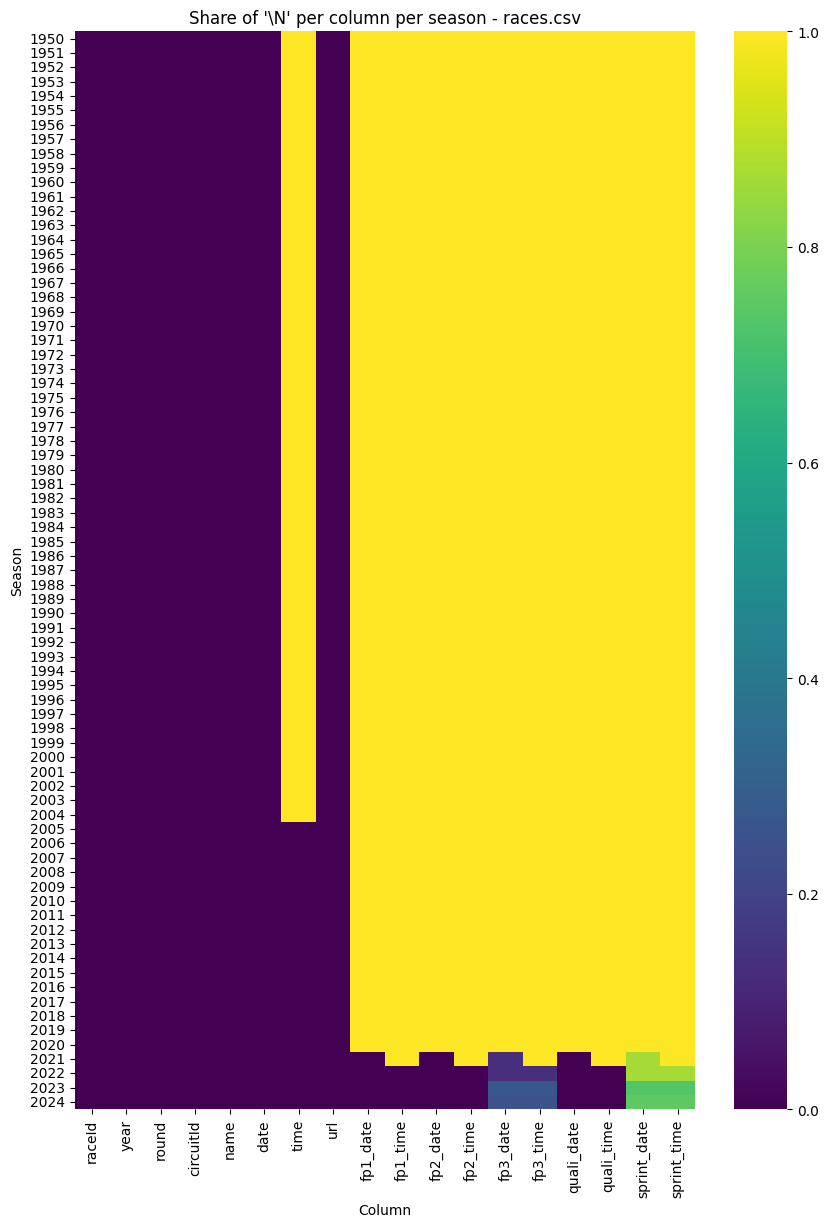

In [143]:
# True where the raw value is the placeholder (a mask only; races is untouched)
mask = (races == SENTINEL)

plt.figure(figsize=(10, 14))
sns.heatmap(mask.groupby(races.year).mean(), cmap='viridis')
plt.title("Share of '\\N' per column per season - races.csv")
plt.xlabel('Column')
plt.ylabel('Season')
plt.show()

In [144]:
coverage = pd.DataFrame({
    'n_sentinel': mask.sum(),
    'pct_sentinel': (mask.mean() * 100).round(1),
    'first_year_with_value': {c: races.loc[~mask[c], 'year'].min() for c in races.columns},
    'last_year_missing': {c: races.loc[mask[c], 'year'].max() for c in races.columns},
})
coverage

,n_sentinel,pct_sentinel,first_year_with_value,last_year_missing
raceId,0,0.0,1950,NaN
year,0,0.0,1950,NaN
round,0,0.0,1950,NaN
circuitId,0,0.0,1950,NaN
name,0,0.0,1950,NaN
date,0,0.0,1950,NaN
time,731,65.0,2005,2004.0
url,0,0.0,1950,NaN
fp1_date,1035,92.0,2021,2020.0
fp1_time,1057,94.0,2022,2021.0


**Findings**
- Seven columns are complete: `raceId`, `year`, `round`, `circuitId`, `name`, `date`, `url`.
- Missingness follows **eras**, not chance:
  - `time` (race start time) is missing up to 2004 and recorded from 2005 (65% `\N`).
  - Practice and qualifying **dates** are recorded from 2021 (92% `\N`); their **times** from 2022 (94% `\N`), so 2021 has dates but no times.
  - `fp3_*` and `sprint_*` are still partly missing in 2023–2024 (visible as partial shading in the heatmap). Section 2.6 explains why.
- Every column except `fp3_*` and `sprint_*` has a clean cut-off: its last missing season comes right before its first recorded season.

**Implications**
- Under the split proposed in the F1 background document (train ≤ 2019, validation 2020–2021, test ≥ 2022), every `fp*`, `quali_*` and `sprint_*` column is **100% `\N` in the training set**. A model cannot learn from a column that is empty throughout training, so these columns are not used as features, regardless of how they would be imputed.
- Columns carried into the modelling table: `raceId`, `year`, `round`, `circuitId`, `name`, `date`. `time` and `url` are kept for reference only.

### 2.6 Explaining the missingness
**Question:** is each `\N` an unknown value (the session happened but was not recorded), or does it mean the session did not exist on that weekend?

This distinction drives cleaning: an unknown value is genuinely missing, while "did not exist" is a real answer that should not be imputed. Sprint races only exist from 2021, and sprint weekends drop the third practice session (FP3), so we check both.

In [145]:
# number of sprint weekends per season (seasons with none are not shown)
(races.sprint_date != SENTINEL).groupby(races.year).sum().loc[lambda s: s > 0]

year
2021    3
2022    3
2023    6
2024    6
Name: sprint_date, dtype: int64

**Check A:** within 2021-2024, is FP3 missing on exactly the sprint weekends and nowhere else? A perfect diagonal in the table below would confirm it.

In [146]:
r21 = races[races.year >= 2021]
is_sprint = r21.sprint_date != SENTINEL

pd.crosstab(is_sprint, r21.fp3_date == SENTINEL,
            rownames=['sprint weekend'], colnames=['fp3 missing'])

fp3 missing,False,True
sprint weekend,,
False,72,0
True,0,18


**Question:** where the schedule is recorded, does qualifying always take place **before** the race?

The project predicts podiums using only information available after qualifying and before the race starts. This checks that the schedule supports that cut-off: a gap of 0 or a negative number of days would be a problem.

In [147]:
q = races[races.quali_date != SENTINEL]
gap = (pd.to_datetime(q.date) - pd.to_datetime(q.quali_date)).dt.days
gap.value_counts().sort_index()

1    77
2    13
Name: count, dtype: int64

**Check B:** does the qualifying-to-race gap depend on whether the weekend has a sprint?

In [148]:
pd.crosstab(gap, (q.sprint_date != SENTINEL),
            rownames=['days quali -> race'], colnames=['sprint weekend'])

sprint weekend,False,True
days quali -> race,,
1,71,6
2,1,12


The cell below lists the weekends that do not follow the main pattern (sprint weekends with a 1-day gap, and normal weekends with a 2-day gap), so they can be inspected individually.

In [149]:
q2 = q.assign(gap=gap, sprint=q.sprint_date != SENTINEL)
q2[(q2.sprint & (q2.gap == 1)) | (~q2.sprint & (q2.gap == 2))] \
    [['year', 'round', 'name', 'quali_date', 'sprint_date', 'date', 'gap']]

,year,round,name,quali_date,sprint_date,date,gap
1099,2023,21,Las Vegas Grand Prix,2023-11-17,\N,2023-11-19,2
1105,2024,5,Chinese Grand Prix,2024-04-20,2024-04-20,2024-04-21,1
1106,2024,6,Miami Grand Prix,2024-05-04,2024-05-04,2024-05-05,1
1111,2024,11,Austrian Grand Prix,2024-06-29,2024-06-29,2024-06-30,1
1119,2024,19,United States Grand Prix,2024-10-19,2024-10-19,2024-10-20,1
1121,2024,21,São Paulo Grand Prix,2024-11-02,2024-11-02,2024-11-03,1
1123,2024,23,Qatar Grand Prix,2024-11-30,2024-11-30,2024-12-01,1


**Check:** the Las Vegas 2023 outlier. If the race start time is early on the Sunday (UTC), the race was held on Saturday night local time and the 2-day gap is an artefact of storing dates in UTC.

In [150]:
races.loc[(races.year == 2023) & races.name.str.contains('Las Vegas'),
          ['name', 'quali_date', 'quali_time', 'date', 'time']]

,name,quali_date,quali_time,date,time
1099,Las Vegas Grand Prix,2023-11-17,08:00:00,2023-11-19,06:00:00


**Findings**
- There are 18 sprint weekends: 3 in 2021, 3 in 2022, 6 in 2023 and 6 in 2024.
- **Check A** is a perfect diagonal: FP3 is missing on exactly the 18 sprint weekends and nowhere else in 2021–2024.
- So `\N` has **two different meanings** in this table:
  - **unrecorded**: the session happened but was not logged (sessions before 2021, race start times before 2005). This is genuinely missing data.
  - **did not exist**: no FP3 on sprint weekends, no sprint on normal weekends. This is a real answer and must not be imputed.
- Qualifying is always 1 or 2 days before the race, never on race day or after it, so the schedule supports the project's prediction cut-off (after qualifying, before the race).
- **The gap pattern is explained by the sprint format changes:**
  - The six sprint weekends with a 1-day gap are all in 2024, where `quali_date` equals `sprint_date` (Saturday).
  - The 12 sprint weekends with a 2-day gap are therefore exactly those of 2021–2023 (3 + 3 + 6), where qualifying was on Friday.
- **Las Vegas 2023** (the one normal weekend with a 2-day gap): qualifying is stored as 17 Nov 08:00 and the race as 19 Nov 06:00. Read as UTC, that is Friday 00:00 and Saturday 22:00 Las Vegas time (UTC−8), a 1-day gap locally. So the outlier comes from **dates and times being stored in UTC**, not from an error. The other race start times (for example 06:00 for the 2009 Australian GP) are also consistent with UTC, so `time` should not be read as a local start time.

**Implications**
- According to the F1 background document, the **sprint result set the Sunday grid in 2021–2022**. On those 6 weekends, `grid` already includes the outcome of a race, so qualifying position and grid differ for a reason other than penalties. This is a caveat for data-engineering Question 1.
- The training period (≤ 2019) contains no sprint weekends, so a sprint flag or sprint-result feature would be constant in training and the model could not learn its effect. Sprint information is therefore not used as a feature.

### 2.7 Circuits
**Questions:**
1. Does a race's name identify the track it was held on?
2. Can the same circuit host more than one race in a season?
3. How many races has each circuit hosted before and after 2014?

These matter for data-engineering Question 1 (which circuits convert a front-row start into a podium, and does that change after the 2014 hybrid era). That question must group by the right identifier, and a circuit with very few races in one era will give an unreliable conversion rate.

In [151]:
# how many different circuits each race name has been held at
races.groupby('name').circuitId.nunique().sort_values(ascending=False).head(10)

name
French Grand Prix           7
European Grand Prix         6
United States Grand Prix    6
Spanish Grand Prix          5
Portuguese Grand Prix       4
British Grand Prix          3
German Grand Prix           3
Belgian Grand Prix          3
Canadian Grand Prix         3
Australian Grand Prix       2
Name: circuitId, dtype: int64

In [152]:
# seasons in which the same circuit hosted more than one race
races[races.duplicated(['year', 'circuitId'], keep=False)] \
    .sort_values(['year', 'circuitId'])[['year', 'round', 'circuitId', 'name', 'date']]

,year,round,circuitId,name,date
1032,2020,15,3,Bahrain Grand Prix,2020-11-29
1033,2020,16,3,Sakhir Grand Prix,2020-12-06
1021,2020,4,9,British Grand Prix,2020-08-02
1022,2020,5,9,70th Anniversary Grand Prix,2020-08-09
1018,2020,1,70,Austrian Grand Prix,2020-07-05
1019,2020,2,70,Styrian Grand Prix,2020-07-12
1043,2021,8,70,Styrian Grand Prix,2021-06-27
1045,2021,9,70,Austrian Grand Prix,2021-07-04


In [153]:
# races per circuit, split at the start of the 2014 hybrid era
circuit_names = raw_before['circuits'].set_index('circuitId')['name']

per_circuit = (races.assign(era=np.where(races.year >= 2014, '2014+', 'pre-2014'))
                    .groupby(['circuitId', 'era']).size().unstack(fill_value=0))
per_circuit['total'] = per_circuit.sum(axis=1)
per_circuit.insert(0, 'circuit', per_circuit.index.map(circuit_names))

per_circuit.sort_values('2014+', ascending=False).head(20)

era,circuit,2014+,pre-2014,total
circuitId,,,,
70,Red Bull Ring,13,25,38
9,Silverstone Circuit,12,47,59
3,Bahrain International Circuit,12,9,21
11,Hungaroring,11,28,39
4,Circuit de Barcelona-Catalunya,11,23,34
14,Autodromo Nazionale di Monza,11,63,74
24,Yas Marina Circuit,11,5,16
13,Circuit de Spa-Francorchamps,11,46,57
6,Circuit de Monaco,10,60,70


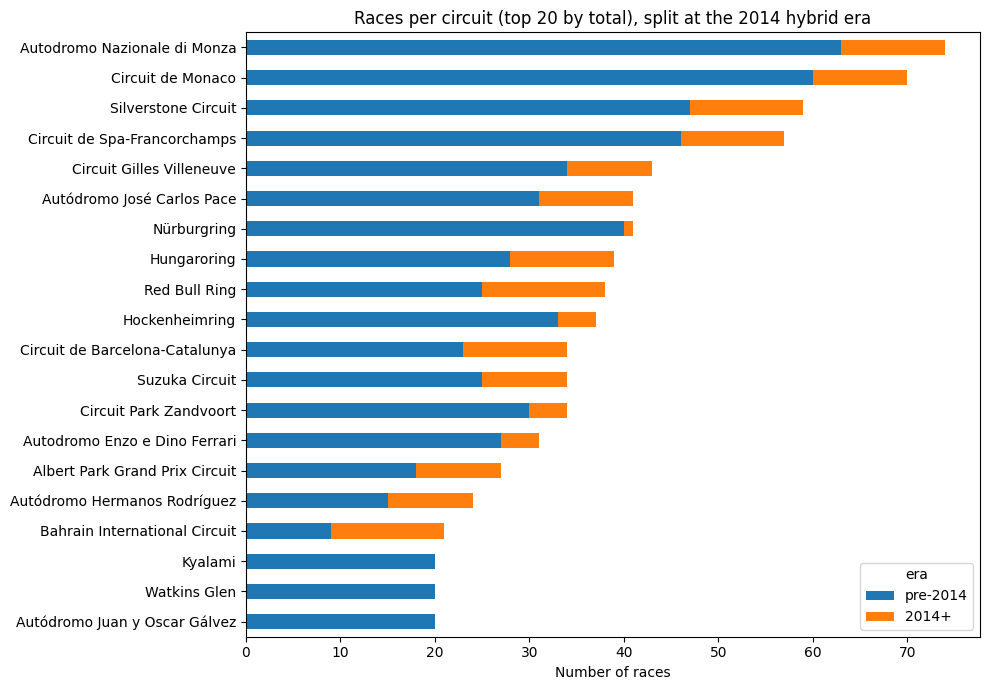

In [154]:
top = per_circuit.sort_values('total', ascending=False).head(20).set_index('circuit')
ax = top[['pre-2014', '2014+']].plot(kind='barh', stacked=True, figsize=(10, 7))
ax.invert_yaxis()
ax.set_xlabel('Number of races')
ax.set_ylabel('')
ax.set_title('Races per circuit (top 20 by total), split at the 2014 hybrid era')
plt.tight_layout()
plt.show()

**Findings**
- A race name does not identify a track: the French GP was held at 7 circuits, the European and United States GPs at 6 each, the Spanish GP at 5.
- The same circuit hosted two races in one season 4 times, all during the 2020–2021 COVID seasons (Bahrain/Sakhir, British/70th Anniversary, Austrian/Styrian twice). These are real, separate races.
- Even the most-used circuit has only 13 races in the 2014+ period (Red Bull Ring).
- Some circuits appear in only one era: among the top 20 by total races, Kyalami, Watkins Glen and Autódromo Juan y Oscar Gálvez have no 2014+ races, while Baku and Sochi have only 2014+ races.

**Implications for data-engineering Question 1**
- Circuit statistics must be grouped by `circuitId`, never by `name`.
- `(year, circuitId)` is not unique, so it must never be used as a join key; use `raceId`.
- Samples are small: a circuit with 9 races in an era has only 18 front-row starts, so a single result moves its conversion rate by about 5.6 percentage points. Q1 needs a minimum number of races per circuit per era, and the counts should be shown next to the rates.
- Only circuits that appear in both eras can answer "does the ranking change".
- **Open decision:** this cell splits at 2014+, which includes the 2022–2024 ground-effect era. The F1 background document defines the hybrid era as 2014–2021, so the team must agree on the era definition for Q1.
- Limitation: as far as we know, the 2020 Sakhir GP used Bahrain's outer layout but shares `circuitId` 3, so one circuit ID can occasionally cover two layouts.

### 2.8 Links to other tables
**Question:** does the races table agree with the tables it connects to?

The brief requires foreign keys to reconcile: every key value must exist in the table it points to. We check that:
- every race has result rows, and every result row points to a known race;
- every `circuitId` exists in the circuits table;
- the seasons table covers exactly the same years;
- the sprint results table covers exactly the sprint weekends.

In [155]:
results  = raw_before['results']
circuits = raw_before['circuits']
seasons  = raw_before['seasons']
sprint   = raw_before['sprint_results']

print('races with no result rows        :', (~races.raceId.isin(results.raceId)).sum())
print('result rows with unknown raceId  :', (~results.raceId.isin(races.raceId)).sum())
print('circuitId not found in circuits  :', (~races.circuitId.isin(circuits.circuitId)).sum())
print('season years differing (set() = none):', set(races.year) ^ set(seasons.year))

sprint_ids = set(races.loc[races.sprint_date != SENTINEL, 'raceId'])
print('races in sprint_results          :', sprint.raceId.nunique())
print('matches the sprint weekends      :', set(sprint.raceId) == sprint_ids)

races with no result rows        : 0
result rows with unknown raceId  : 0
circuitId not found in circuits  : 0
season years differing (set() = none): set()
races in sprint_results          : 18
matches the sprint weekends      : True


**Findings**
- Every race has result rows, and every result row points to a known race.
- Every `circuitId` in `races` exists in `circuits`.
- `races` and `seasons` cover exactly the same 75 seasons (1950–2024).
- `sprint_results` covers exactly the 18 sprint weekends and nothing else.

**Implications**
- All foreign keys linked to `races` reconcile, as the brief requires.
- There are no scheduled-but-unrun races that would need removing from the modelling table.

### 2.9 Special case: the Indianapolis 500
**Question:** where is the Indianapolis 500 in the data?

The F1 background document flags it as a special case: it counted towards the championship from 1950 to 1960, but almost no regular F1 drivers entered it. Locating these races now lets us make, and document, a decision about whether to keep them.

In [156]:
indy = races[races.name.str.contains('Indianapolis')]
print(indy.year.agg(['min', 'max', 'count']))
indy[['raceId', 'year', 'round', 'circuitId', 'name', 'date']]

min      1950
max      1960
count      11
Name: year, dtype: int64


,raceId,year,round,circuitId,name,date
747,748,1960,3,19,Indianapolis 500,1960-05-30
756,757,1959,2,19,Indianapolis 500,1959-05-30
767,768,1958,4,19,Indianapolis 500,1958-05-30
777,778,1957,3,19,Indianapolis 500,1957-05-30
785,786,1956,3,19,Indianapolis 500,1956-05-30
793,794,1955,3,19,Indianapolis 500,1955-05-30
799,800,1954,2,19,Indianapolis 500,1954-05-31
808,809,1953,2,19,Indianapolis 500,1953-05-30
817,818,1952,2,19,Indianapolis 500,1952-05-30
825,826,1951,2,19,Indianapolis 500,1951-05-30


**Check:** which races were held on the Indianapolis circuit (`circuitId` 19)? If the Indy 500 is not the only one, it must be identified by name, not by circuit.

In [157]:
races[races.circuitId == 19].groupby('name').year.agg(['min', 'max', 'count'])

,min,max,count
name,,,
Indianapolis 500,1950,1960,11
United States Grand Prix,2000,2007,8


**Findings**
- The Indianapolis 500 appears 11 times, once per season from 1950 to 1960, always on `circuitId` 19, matching the F1 background document.
- `circuitId` 19 was **also used by the United States Grand Prix from 2000 to 2007** (8 races).

**Implications**
- The Indy 500 must be identified by `name` (or its 11 `raceId`s), **not** by `circuitId`. Filtering on `circuitId == 19` would wrongly remove 8 regular Grands Prix.
- **Proposed decision:** exclude the Indy 500 from data-engineering Question 2 (home advantage), because it inflates race counts for American drivers. For the model it does not matter if the training window starts after 1960 (see Section 3).

### 2.10 Summary of the races audit

**What is clean**
- `raceId` is a valid primary key; `(year, round)` is a valid alternative key.
- Every season has rounds 1..n, every date is valid, and round order matches calendar order.
- All foreign keys linked to `races` reconcile (results, circuits, seasons, sprint results).

**What is missing, and why**
- `\N` is invisible to pandas and must be handled explicitly.
- Missingness depends on the era: race start times from 2005, session dates from 2021, session times from 2022.
- Some `\N` values mean the session **did not exist** (FP3 on sprint weekends, sprints before 2021), not that a value was lost.
- Dates and times are stored in UTC, which explains the one remaining schedule outlier (Las Vegas 2023).

**Decisions carried into cleaning and modelling**
- Keep `raceId`, `year`, `round`, `circuitId`, `name`, `date` for the modelling table; convert `date` to a datetime.
- Do not use schedule or sprint columns as features: they are entirely empty in the training period.
- Order races by `date` or `(year, round)`, never by `raceId`.
- Group circuit-level analysis by `circuitId` and apply a minimum sample size.
- Flag 2021–2022 sprint weekends, where the grid came from the sprint result.
- Identify the Indianapolis 500 by `name`, not by `circuitId` (shared with the 2000–2007 US GP); exclude it from Q2.

**Open question for the team**
- The era definition for Q1 (pre-2014 vs 2014+, or a separate 2022+ era).
- The training window is addressed by the coverage evidence in Section 3.

## 3. How the other tables cover each race
**Question:** for which races does each of the other race-level tables actually have data?

Every table below links to `races` through `raceId`. The races table tells us *which* races exist; this section tells us *how much we know about each one*. That decides which information can be used for which seasons, and so shapes the training window and the feature list.

| Table | Linked by | Known before the race starts? | What it tells us |
|---|---|---|---|
| `qualifying` | `raceId` | Yes | Qualifying position and lap times; the source of the qualifying-coverage drift |
| `sprint_results` | `raceId` | Yes (Saturday) | Sprint outcome; a leakage judgement call |
| `driver_standings`, `constructor_standings` | `raceId` | Only the **previous** race's row | Championship form; must be shifted (Section 5) |
| `constructor_results` | `raceId` | No | A team's points in that race |
| `lap_times`, `pit_stops` | `raceId` | No | Post-race only; never features |
| `circuits` | `circuitId` | Yes (static) | Where the race is held (Section 4) |
| `results` | `raceId` | No (contains the target) | Analysed separately by a teammate; used here only to count entrants |

### 3.1 Coverage per season
The heatmap shows, for each season, the share of races that have at least one row in each table. The table underneath gives the first and last season with data, and how many races are missing **after** the first covered season. If that last number is 0, the table has a clean start date rather than scattered gaps.

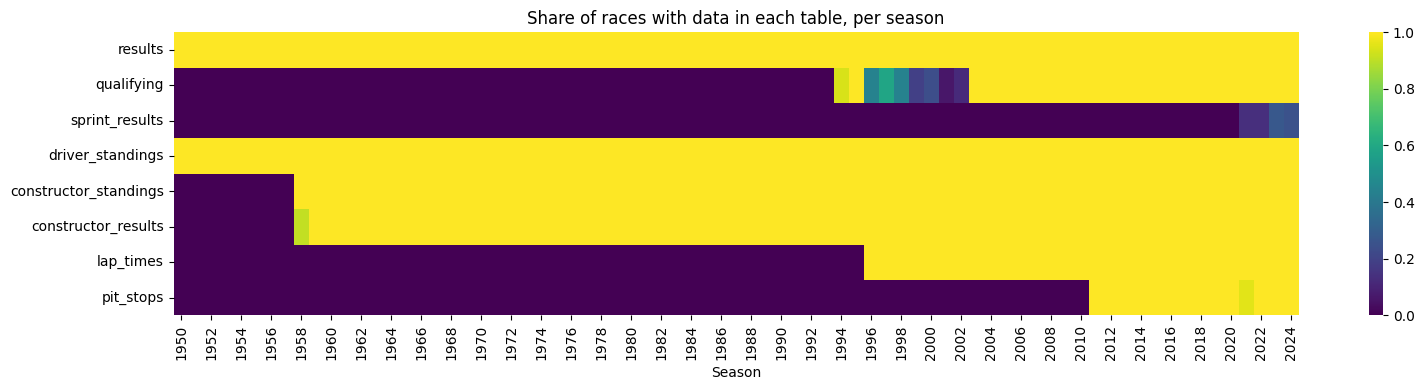

In [158]:
race_tables = ['results', 'qualifying', 'sprint_results', 'driver_standings',
               'constructor_standings', 'constructor_results', 'lap_times', 'pit_stops']

# True where the race has at least one row in that table
covered = pd.DataFrame({t: races.raceId.isin(raw_before[t].raceId) for t in race_tables})

plt.figure(figsize=(16, 4))
sns.heatmap(covered.groupby(races.year).mean().T, cmap='viridis', vmin=0, vmax=1)
plt.title('Share of races with data in each table, per season')
plt.xlabel('Season')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [159]:
first_season = {t: races.loc[covered[t], 'year'].min() for t in race_tables}

pd.DataFrame({
    'races_covered': covered.sum(),
    'pct_of_races': (covered.mean() * 100).round(1),
    'first_season': first_season,
    'last_season': {t: races.loc[covered[t], 'year'].max() for t in race_tables},
    'races_missing_after_first': {t: ((races.year >= first_season[t]) & ~covered[t]).sum()
                                  for t in race_tables},
})

,races_covered,pct_of_races,first_season,last_season,races_missing_after_first
results,1125,100.0,1950,2024,0
qualifying,494,43.9,1994,2024,83
sprint_results,18,1.6,2021,2024,72
driver_standings,1125,100.0,1950,2024,0
constructor_standings,1061,94.3,1958,2024,0
constructor_results,1060,94.2,1958,2024,1
lap_times,544,48.4,1996,2024,0
pit_stops,285,25.3,2011,2024,1


The cell below lists the single race missing from `constructor_results` and from `pit_stops` after each table's first season, so the gaps can be explained individually.

In [160]:
for t in ['constructor_results', 'pit_stops']:
    gaps = races[(races.year >= first_season[t]) & ~covered[t]]
    print(t)
    print(gaps[['raceId', 'year', 'round', 'name', 'date']].to_string(index=False), '\n')

constructor_results
 raceId  year  round             name       date
    768  1958      4 Indianapolis 500 1958-05-30 

pit_stops
 raceId  year  round               name       date
   1063  2021     12 Belgian Grand Prix 2021-08-29 



**Findings**

| Table | Covers | From | Gaps after the first season |
|---|---|---|---|
| `results`, `driver_standings` | every race | 1950 | none |
| `constructor_standings`, `constructor_results` | 94% of races | 1958 | `constructor_results` misses 1 race |
| `qualifying` | 44% of races | 1994 | **83 races**, concentrated in 1996–2002 |
| `lap_times` | 48% of races | 1996 | none |
| `pit_stops` | 25% of races | 2011 | 1 race |
| `sprint_results` | 18 races | 2021 | only sprint weekends, as expected (2.8) |

- Constructor tables start in **1958**, the first season of the Constructors' Championship according to the F1 background document. This is a structural start, not missing data: there were no constructor standings before 1958.
- `qualifying` has a start (1994) **and** a large gap afterwards: from 2003 onwards every race is covered; between 1996 and 2002 most races have no qualifying rows at all (the heatmap's partial shading). This is the qualifying-coverage drift the brief warns about, now located precisely.
- `lap_times` and `pit_stops` are post-race data and are never used as features; their coverage matters only for the report.
- The two single-race gaps listed by the cell above are both explainable rather than lost data:
  - `constructor_results` is missing the **1958 Indianapolis 500**. That race is already a special case (2.9); as far as we know it did not count towards the Constructors' Championship, which would explain the gap.
  - `pit_stops` is missing the **2021 Belgian GP**. As far as we know, that race was run only behind the safety car for a few laps because of rain, so no pit stops took place.
  Both explanations come from F1 history, not from this dataset, and should be stated as such in the report.

**Implications**
- A constructor-standings feature cannot exist before 1958, so a training window starting before 1958 would need a separate rule for those seasons.
- Qualifying-based features are only fully available from **2003**. Section 3.2 checks how complete qualifying is *within* each race.

### 3.2 How complete is qualifying within each race?
**Question:** in races that do have qualifying data, does every entrant have a qualifying row?

A race can appear in `qualifying` while still missing some drivers (for example, entrants who failed to pre-qualify). This compares, per season, the number of qualifying rows with the number of entrants. **It only counts rows per race; no values from `results` are analysed.**

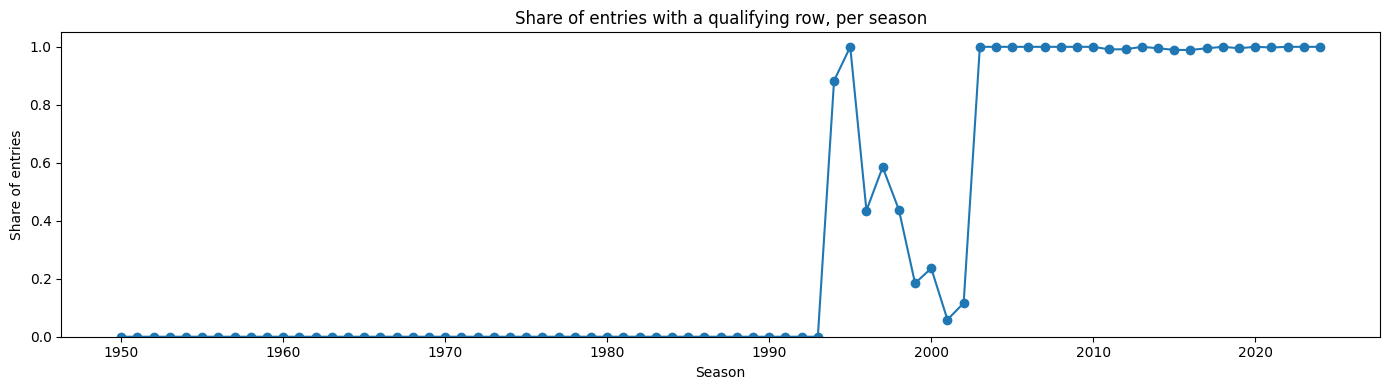

,entrants,in_qualifying,share
year,,,
1994,444,392.0,0.882883
1995,418,418.0,1.000000
1996,340,148.0,0.435294
1997,376,220.0,0.585106
1998,349,153.0,0.438395
1999,352,65.0,0.184659
2000,373,88.0,0.235925
2001,374,22.0,0.058824
2002,362,42.0,0.116022


In [161]:
entrants = raw_before['results'].groupby('raceId').size()
in_quali = raw_before['qualifying'].groupby('raceId').size()

depth = pd.DataFrame({'entrants': entrants, 'in_qualifying': in_quali}).fillna(0)
depth['year'] = depth.index.map(races.set_index('raceId')['year'])

per_season = depth.groupby('year')[['entrants', 'in_qualifying']].sum()
per_season['share'] = per_season.in_qualifying / per_season.entrants

ax = per_season['share'].plot(figsize=(14, 4), marker='o')
ax.set_title('Share of entries with a qualifying row, per season')
ax.set_xlabel('Season')
ax.set_ylabel('Share of entries')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

per_season[per_season.share > 0].head(15)

**Findings**
- **1950–1993:** no entrant has a qualifying row.
- **1994–1995:** almost complete (88% and 100% of entries).
- **1996–2002:** coverage collapses and fluctuates, between 6% (2001) and 59% (1997) of entries. Most rows are missing entirely, not just the later qualifying parts. The F1 background document expected "mostly q1 only" for these seasons, but our copy shows that whole rows are absent.
- **2003–2024:** essentially complete (100%, with a few seasons slightly below, meaning a handful of entrants without a qualifying row).

**Implications for the training window**

The brief and the F1 background document name three options for qualifying coverage drift. The evidence above gives each option a concrete cost:

| Option | What it means here | Cost |
|---|---|---|
| Restrict the window to **2003–2019** for training | Qualifying features are complete in training, validation and test | 17 training seasons; loses older data (which comes from very different eras anyway) |
| Train from earlier and **fall back to `grid`** before 2003 | `grid` exists for every season | Qualifying position and grid are not the same (penalties, pit-lane starts), so the feature changes meaning across the split point |
| Train from earlier and **impute** qualifying | Fill missing qualifying values | About 60% of all entries would be imputed; values would be invented for whole eras |

Restricting training to 2003–2019 is the simplest option to defend from this evidence, but it is a team decision. If the team wants to compare options empirically, the brief's "before/after baseline" approach applies: train once on each window and compare validation scores.

## 4. Circuits: where the races are held
**Question:** what does the circuits table add to each race, and is it ready for the circuit-level (Q1) and home-race (Q2) questions?

`races` only stores a `circuitId`. Joining `circuits` gives the circuit's name, city, country and coordinates. Q1 is answered per circuit, and Q2 needs each race's **country** to decide whether it is a driver's home race.

### 4.1 Structure and keys

In [162]:
circuits = raw_before['circuits']

print('circuitId unique  :', circuits.circuitId.is_unique)
print('circuitId nulls   :', circuits.circuitId.isna().sum())
print('circuits never raced on:', (~circuits.circuitId.isin(races.circuitId)).sum())
print()
print(circuits.dtypes)
print()
print("'\\N' per column:")
print((circuits == SENTINEL).sum())
circuits.head()

circuitId unique  : True
circuitId nulls   : 0
circuits never raced on: 0

circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object

'\N' per column:
circuitId     0
circuitRef    0
name          0
location      0
country       0
lat           0
lng           0
alt           0
url           0
dtype: int64


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


**Findings**
- `circuitId` is unique and non-null, so it is a valid primary key.
- All 77 circuits were used by at least one race, so there are no unused rows.
- The table has **no `\N`** in any column. `lat` and `lng` are already numeric (`float64`), and `alt` is an integer.

**Implication:** `circuits` needs no sentinel cleaning. The join from `races` to `circuits` is safe (verified in 2.8 and again with `validate='many_to_one'` in 4.2).

### 4.2 Races per country, and how the calendar spread over time
**Question:** which countries host the most races, and how many different countries appear on the calendar each season?

The join is checked with `validate='many_to_one'`, so pandas raises an error if any `circuitId` matched more than one circuit. More host countries per season means more "home race" opportunities for drivers from those countries, which matters for Q2.

(1125, 23)


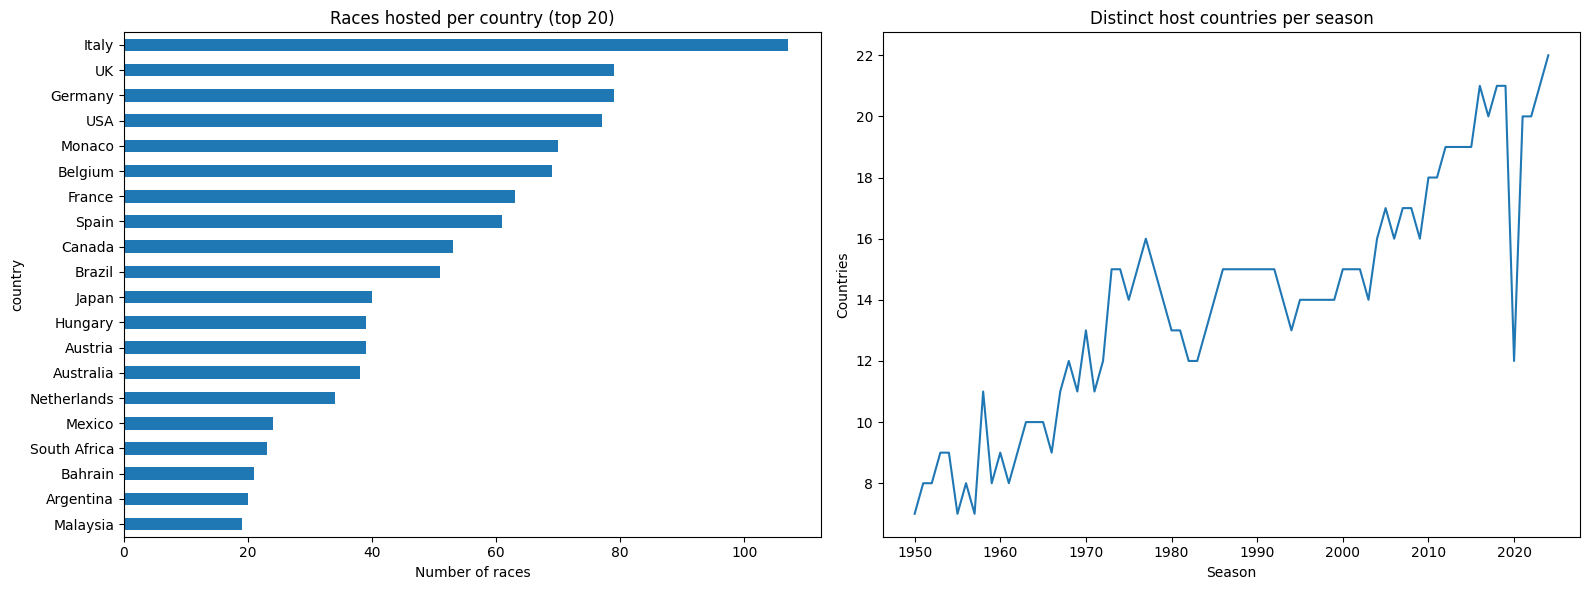

In [163]:
rc = races.merge(
    circuits[['circuitId', 'name', 'location', 'country', 'lat', 'lng']]
        .rename(columns={'name': 'circuit'}),
    on='circuitId', how='left', validate='many_to_one')
print(rc.shape)   # should have the same number of rows as races (1125)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

rc.country.value_counts().head(20).sort_values().plot(kind='barh', ax=ax[0])
ax[0].set_title('Races hosted per country (top 20)')
ax[0].set_xlabel('Number of races')

rc.groupby('year').country.nunique().plot(ax=ax[1])
ax[1].set_title('Distinct host countries per season')
ax[1].set_xlabel('Season')
ax[1].set_ylabel('Countries')

plt.tight_layout()
plt.show()

**Findings**
- The join keeps all 1,125 races (one circuit per race).
- **Italy hosts the most races** (over 100). Italy has two long-standing venues (Monza and Imola); races run under another country's name at an Italian circuit, such as the San Marino GP at Imola, are counted as Italy because `country` describes where the circuit is.
- The number of distinct host countries grows from 7 in 1950 to 22 in 2024, with a sharp dip to 12 in 2020 (COVID calendar).
- `country` contains **both `USA` and `United States`** (see 4.4). The bar chart therefore splits American races across two labels and undercounts the USA bar.

**Implications for Q2 (home races)**
- "Home race" must be decided from the circuit's `country`, not from the race name: a race name can refer to a country other than the one the circuit is in (San Marino GP, European GP, 70th Anniversary GP).
- The two USA labels must be merged during cleaning, or every American driver's home races would be partly missed.
- Before 2000, fewer countries hosted races, so fewer drivers had a home race at all. Home-race comparisons are therefore era-sensitive.

### 4.3 Where the circuits are
Each point is a circuit, placed by its coordinates and sized by how many races it hosted. Colour shows the first season it was used. This gives a quick visual check that the coordinates are plausible and shows how the calendar moved beyond Europe over time.

circuits with unreadable coordinates: 0


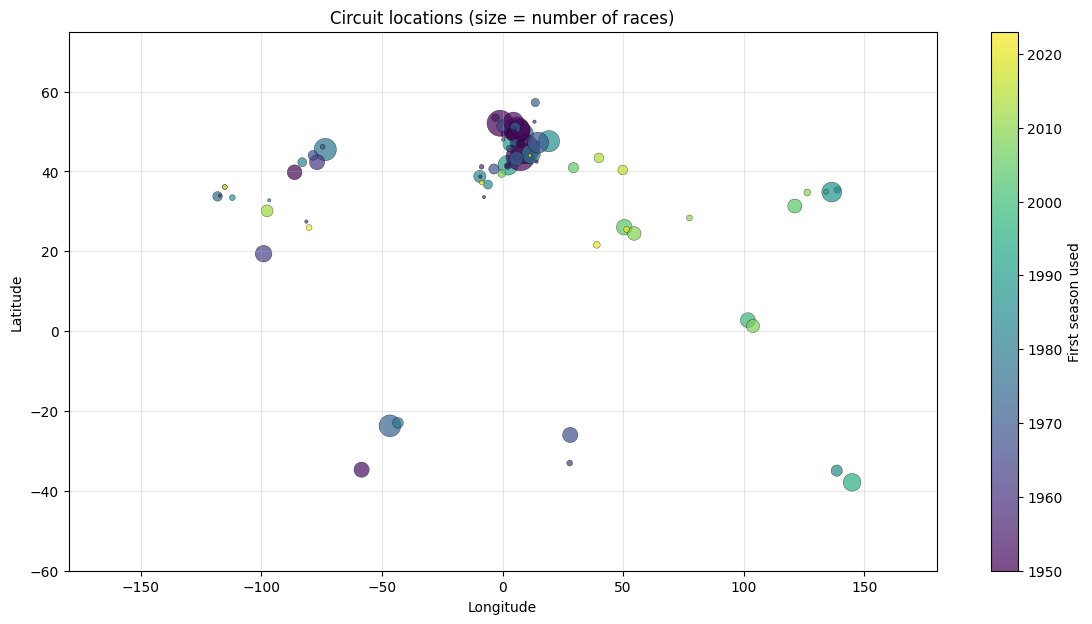

In [164]:
geo = (rc.assign(lat=pd.to_numeric(rc.lat, errors='coerce'),
                 lng=pd.to_numeric(rc.lng, errors='coerce'))
         .groupby(['circuitId', 'circuit'])
         .agg(lat=('lat', 'first'), lng=('lng', 'first'),
              races=('raceId', 'size'), first_year=('year', 'min'))
         .reset_index())
print('circuits with unreadable coordinates:', geo[['lat', 'lng']].isna().any(axis=1).sum())

plt.figure(figsize=(14, 7))
sc = plt.scatter(geo.lng, geo.lat, s=geo.races * 6, c=geo.first_year,
                 cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, label='First season used')
plt.title('Circuit locations (size = number of races)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-180, 180)
plt.ylim(-60, 75)
plt.grid(alpha=0.3)
plt.show()

**Findings**
- All 77 circuits have readable coordinates, and the plot shows them on the expected continents. There are no points at (0, 0) or other obviously wrong placements.
- The oldest and most-used circuits (largest, darkest points) are concentrated in Western Europe.
- Newer circuits (lighter colours) are mostly in the Middle East, Asia and the Americas, confirming the calendar's expansion seen in 4.2.

**Implication:** the location data is usable as-is. The shift away from Europe also means a driver's chance of having a home race on the calendar depends on the season (relevant to Q2).

### 4.4 Country names vs. driver nationalities (preparing Q2)
**Question:** can a driver's nationality be matched directly to a circuit's country?

Q2 needs to decide whether each race is in the driver's home country. The `drivers` table stores a nationality (an adjective such as "British"), while `circuits` stores a country name (such as "UK"). The two lists below show both vocabularies, so a mapping between them can be built and checked rather than assumed.

In [165]:
drivers = raw_before['drivers']

print('Circuit countries   (', circuits.country.nunique(), '):')
print(sorted(circuits.country.unique()))
print()
print('Driver nationalities (', drivers.nationality.nunique(), '):')
print(sorted(drivers.nationality.unique()))

Circuit countries   ( 35 ):
['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']

Driver nationalities ( 43 ):
['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian ', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai', 'Uruguayan', 'Venezuelan']


**Findings**
- There are 35 circuit countries and 43 driver nationalities. They use different vocabularies (country names vs. adjectives), so they cannot be matched directly. A mapping such as `British → UK`, `Dutch → Netherlands`, `Monegasque → Monaco` must be built and documented.
- **Data-quality issues found:**
  - `USA` and `United States` are two labels for the same country in `circuits`.
  - `Argentine` and `Argentinian ` (with a trailing space) are two labels for the same nationality in `drivers`.
  - Some nationalities are combined (`American-Italian`, `Argentine-Italian`), so a rule is needed for which country counts as home.
  - Some refer to former states: `East German` (could map to Germany) and `Rhodesian` (no circuit country).
- Many nationalities have **no circuit country at all** (for example Finnish, Danish, New Zealander, Chilean, Colombian, Irish, Polish, Czech, Thai). Drivers with these nationalities never had a home race in this data.
- Some host countries have **no drivers** of that nationality in the data (for example Azerbaijan, Bahrain, Qatar, Saudi Arabia, Singapore, Turkey, UAE).

**Implications for Q2**
- Clean both vocabularies first (merge the duplicate labels, strip whitespace), then map nationality to country with an explicit, documented table.
- Drivers who could never race at home should be excluded from the home-vs-away comparison. Otherwise they only add "away" rows and dilute the comparison.
- The mapping choices (combined nationalities, East German, Rhodesian) must be stated in the report as assumptions.

## 5. Championship standings: before or after the race?
**Question:** does the standings row attached to a race describe the championship **before** that race or **after** it?

The F1 background document says standings must be shifted to "standings before this race" to be leakage-safe. We test this directly: if the standings row for **round 1** already shows points, it must include the result of round 1 itself, because no points exist before the first race of a season.

In [166]:
ds = raw_before['driver_standings'].merge(races[['raceId', 'year', 'round', 'name']],
                                          on='raceId', validate='many_to_one')
pts = pd.to_numeric(ds.points, errors='coerce')

r1 = ds[ds['round'] == 1]
print('standings rows at round 1           :', len(r1))
print('of which already have points > 0    :', (pts[r1.index] > 0).sum())

# example: the leaders after round 1 of the latest season
latest = r1[r1.year == r1.year.max()]
latest.assign(points=pts[latest.index]).sort_values('points', ascending=False) \
      [['year', 'round', 'name', 'driverId', 'points', 'position', 'wins']].head(5)

standings rows at round 1           : 1521
of which already have points > 0    : 518


,year,round,name,driverId,points,position,wins
34360,2024,1,Bahrain Grand Prix,830,26.0,1,1
34359,2024,1,Bahrain Grand Prix,815,18.0,2,0
34358,2024,1,Bahrain Grand Prix,832,15.0,3,0
34357,2024,1,Bahrain Grand Prix,844,12.0,4,0
34356,2024,1,Bahrain Grand Prix,847,10.0,5,0


**Findings**
- There are 1,521 standings rows at round 1, and **518 of them already have points**.
- Example: after round 1 of 2024 (Bahrain), the leader already has 26 points and 1 win.
- Since no points exist before the first race of a season, the standings row for a race **already includes that race's result**.

**Implications**
- `driver_standings` (and, by the same logic, `constructor_standings`) are recorded **after** each race. Using the row for the race being predicted would be **data leakage**: it encodes whether the driver scored points, and therefore whether they finished well.
- A leakage-safe standings feature must use the row from the **previous race in the same season**, ordered by `(year, round)`, not by `raceId` (see 2.1).
- At round 1 there are no earlier standings in that season. This value is structurally missing (every driver starts on 0 points), not lost data, and should be filled with 0 rather than imputed from other rows.

## 6. What this audit gives the rest of the pipeline

| Finding | Evidence | Used in |
|---|---|---|
| `\N` is invisible to pandas; two kinds of `\N` (unrecorded vs. did not exist) | 2.1, 2.5, 2.6 | Cleaning: sentinel handling |
| `date` is text; dates and times are stored in UTC | 2.1, 2.6 | Cleaning: semantic typing |
| All keys valid; all foreign keys linked to `races` reconcile | 2.2, 2.8, 4.1 | Cleaning: key verification |
| Order races by `date` or `(year, round)`, never by `raceId` | 2.1, 2.4 | Leakage-safe form and standings features |
| Standings are recorded **after** each race | 5 | Standings features must use the previous race |
| Season length grows from 7 to 24 races | 2.3 | Form features as rates, not counts |
| Schedule and sprint columns are empty in the training period | 2.5, 2.6 | Feature selection: excluded |
| Qualifying is complete only from 2003 | 3.1, 3.2 | Training window; known limitation |
| Constructor tables start in 1958 | 3.1 | Constructor features; training window |
| 2021–2022 grid came from the sprint result | 2.6 | Q1 caveat; grid feature caveat |
| Group by `circuitId`; small samples per era | 2.7 | Q1 method and minimum-sample rule |
| Home country comes from `circuits.country`; vocabularies need cleaning and a mapping | 4.2, 4.4 | Q2 method |
| Indy 500 shares `circuitId` 19 with the 2000–2007 US GP | 2.9 | Exclude Indy 500 by name |

**Decisions for the team**
1. Training window: 2003–2019 (complete qualifying) vs. an earlier start with a grid fallback.
2. Era definition for Q1: pre-2014 vs. 2014+, or a separate 2022–2024 era.
3. Nationality-to-country mapping rules for Q2 (combined nationalities, former states).